In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")
import jax
print(jax.devices())

[CudaDevice(id=0)]


In [3]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
import equinox as eqx
import matplotlib.pyplot as plt
import time

from ABCMB import main, cosmology, perturbations, spectrum, model_specs, species
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

# Setup

In [21]:
params = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    #'Neff': 3.044,
    #'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.7163685,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    #'T_nu_massive': 0.71611,
    #'m_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

lmax = 2500
specs = {
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : True,
    "output_Pk" : True,
    "output_k_max" : 0.4,
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17,
    "l_max_ncdm" : 17
}
if params["N_nu_massive"] > 0:
    user_species = (
        species.MassiveNeutrino,
    )
else:
    user_species = None

model = main.Model(user_species=user_species, input_specs=specs, return_PTBG=True, bbn_type="linX")
#model = main.Model(user_species=user_species, input_specs=specs, return_PTBG=True)
#params = eqx.filter_jit(model.add_derived_parameters)(params)
#params

In [6]:
# This is with params = {"Neff" : 3.044}
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)

172.86636996269226
9.871554136276245


In [8]:
# This is with params = {}
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)

You did not specify either T_nu_massless or Neff, and did not ask LINX to compute these quantities. Defaulting to LCDM values
143.59158754348755
9.82637071609497


In [10]:
# This is with params we always run with
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)

173.59109830856323
9.84578561782837


In [12]:
# This is with params above but got rid of Neff
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)

You did not specify either T_nu_massless or Neff, and did not ask LINX to compute these quantities. Defaulting to LCDM values
145.74607396125793
9.821406364440918


In [14]:
# This is with params = {"T_nu_massless" : 0.71642}
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)

175.93199706077576
9.702795267105103


In [22]:
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)



            __
           /  \
          /    \
         /   /\ \
            /  \ \     _     _
        /  / /\ \ \   / \   / \ 
          / /__\ \ \_/___\_/___\   __
       / / ______ \  | _ \ / ___\_/  \   _
        / /      \ \ |  _// /    | \/ \_/_\  
______// /        \ \| _ \\ \___ ||\/||| - )/\  
      /_/          \_\___/ \____|||  |||_-_)  \/\ is compiling...
                                                 \/\


214.17401576042175
12.51955771446228


In [23]:
label

(Array([   2,    3,    4, ..., 2498, 2499, 2500], dtype=int64),
 Array([7.04886556e-06, 1.57547521e-05, 2.44911878e-05, 3.32816560e-05,
        4.21500275e-05, 5.11207737e-05, 6.02191857e-05, 6.94716035e-05,
        7.89056579e-05, 8.85505278e-05, 9.84372161e-05, 1.08598847e-04,
        1.19070989e-04, 1.29892000e-04, 1.41103411e-04, 1.52750328e-04,
        1.64881872e-04, 1.77551651e-04, 1.90818247e-04, 2.04745734e-04,
        2.19404189e-04, 2.34870208e-04, 2.51227369e-04, 2.68566636e-04,
        2.86986640e-04, 3.06593782e-04, 3.27502085e-04, 3.49832711e-04,
        3.73713045e-04, 3.99275249e-04, 4.26654209e-04, 4.55984813e-04,
        4.87398560e-04, 5.21019579e-04, 5.56960222e-04, 5.95316500e-04,
        6.36163732e-04, 6.79552814e-04, 7.25507513e-04, 7.74023111e-04,
        8.25066578e-04, 8.78578263e-04, 9.34474911e-04, 9.92653663e-04,
        1.05299662e-03, 1.11537555e-03, 1.17965636e-03, 1.24570305e-03,
        1.31338105e-03, 1.38255985e-03, 1.45311481e-03, 1.52492853e-03,


In [9]:
for i in range(1):
    s = time.time()
    class_params = {
        "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, pCl",
        "P_k_max_1/Mpc" : specs["output_k_max"],
        "l_max_scalars" : lmax,
        "k_output_values" : "0.001, 0.01, 0.1, 0.4",
        "lensing" : "yes" if specs["lensing"] else "no",
        "H0": params["h"]*100,
        "omega_b": params["omega_b"],
        "omega_cdm": params["omega_cdm"],
        "A_s" : params["A_s"],
        "n_s" : params["n_s"],
        "N_ur": params["Neff"],
        "YHe": params["YHe"],
        "N_ncdm": params["N_nu_massive"],
        #"reio_parametrization" : "reio_none",
        "reio_parametrization" : "reio_camb",
        "z_reio" : params["z_reion"],
        "reionization_width" : params["Delta_z_reion"],
        "helium_fullreio_redshift" : params["z_reion_He"],
        "helium_fullreio_width" : params["Delta_z_reion_He"],
        "reionization_exponent" : 1.5,
        "l_max_g": specs["l_max_g"],
        "l_max_pol_g": specs["l_max_pol_g"],
        "l_max_ur": specs["l_max_ur"], 
        "l_max_ncdm":specs["l_max_ncdm"],
        "radiation_streaming_trigger_tau_over_tau_k" : 20000,
        "radiation_streaming_trigger_tau_c_over_tau" : 2000,
        "ur_fluid_trigger_tau_over_tau_k" : 10000, 
        "ncdm_fluid_trigger_tau_over_tau_k" : 15000} 
    class_lcdm = Class()
    class_lcdm.set(class_params)
    if params["N_nu_massive"] > 0:
        class_lcdm.set({"m_ncdm": params["m_nu_massive"], "T_ncdm": params["T_nu_massive"]})
    class_lcdm.compute()
    print(time.time() - s)

24.68644881248474


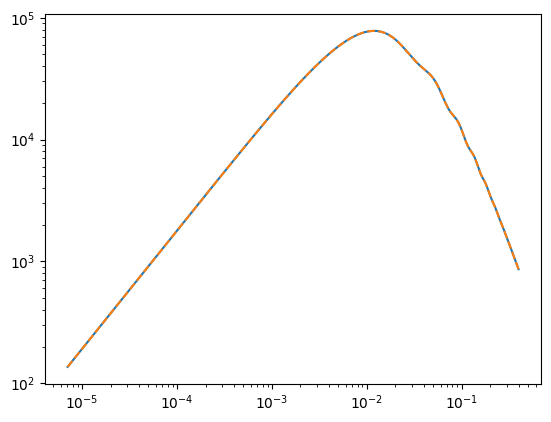

In [10]:
class_pk = np.vectorize(class_lcdm.pk)(label[1], 0.)
plt.loglog(label[1], class_pk)
plt.loglog(label[1], data[3], "--")
#plt.loglog(label[1], model.SS.Pk_cb(label[1], 0., PT, params), "--")
#plt.xlim((0.25, 0.3))
plt.show()

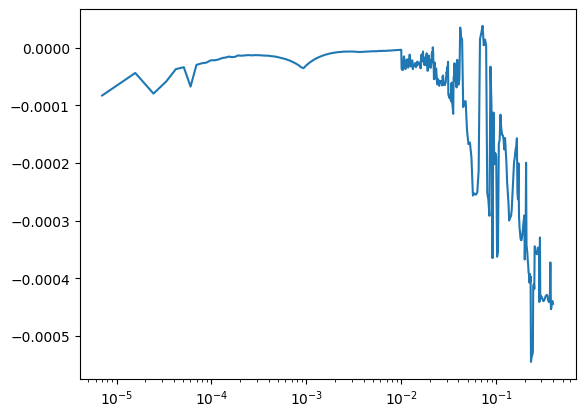

In [11]:
plt.plot(label[1], data[3]/class_pk - 1.)
plt.xscale("log")
plt.show()

# Background Check

## Hubble

In [12]:
class_bg

{'z': array([1.00000000e+14, 9.99194400e+13, 9.98389448e+13, ...,
        1.61314959e-03, 8.06249775e-04, 0.00000000e+00], shape=(40000,)),
 'proper time [Gyr]': array([7.55952024e-26, 7.57171488e-26, 7.58392919e-26, ...,
        1.37830335e+01, 1.37946807e+01, 1.38063323e+01], shape=(40000,)),
 'conf. time [Mpc]': array([4.63478500e-09, 4.63842298e-09, 4.64387995e-09, ...,
        1.41795260e+04, 1.41831014e+04, 1.41866752e+04], shape=(40000,)),
 'H [1/Mpc]': array([2.15725580e+22, 2.15378143e+22, 2.15031265e+22, ...,
        2.25725574e-04, 2.25640721e-04, 2.25556041e-04], shape=(40000,)),
 'comov. dist.': array([1.41866752e+04, 1.41866752e+04, 1.41866752e+04, ...,
        7.14919403e+00, 3.57382802e+00, 0.00000000e+00], shape=(40000,)),
 'ang.diam.dist.': array([1.41866752e-10, 1.41981132e-10, 1.42095604e-10, ...,
        7.13767988e+00, 3.57094894e+00, 0.00000000e+00], shape=(40000,)),
 'lum. dist.': array([1.41866752e+18, 1.41752464e+18, 1.41638268e+18, ...,
        7.16072675e+00

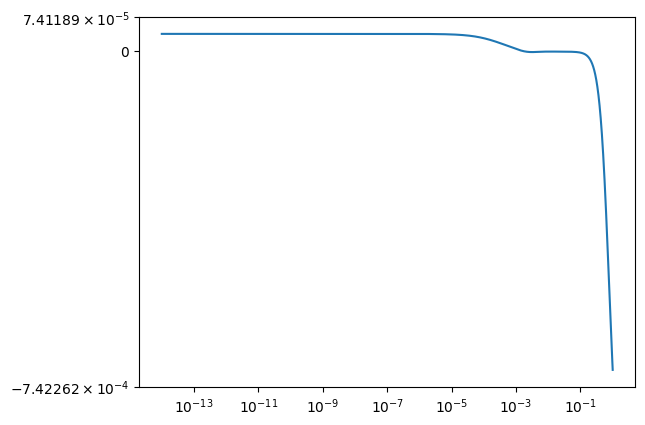

In [41]:
class_bg = class_lcdm.get_background()
a = 1/(1.+class_bg["z"])
H_class = class_bg['H [1/Mpc]'] * cnst.c_Mpc_over_s
H_ABCMB = BG.H(jnp.log(a), params)
plt.plot(a, (H_class - H_ABCMB)/H_class)
plt.yscale("symlog")
plt.xscale("log")
plt.show()

## Massive Neutrino Density

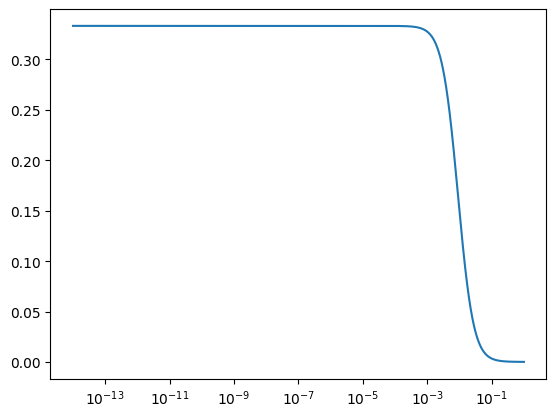

In [42]:
rho_nu_class = class_bg[ '(.)p_ncdm[0]']/class_bg[ '(.)rho_ncdm[0]']
plt.plot(a, rho_nu_class)
#rho_nu_ABCMB = BG.H(jnp.log(a), params)
#plt.plot(a, (H_class - H_ABCMB)/H_class)
#plt.yscale("symlog")
#plt.xscale("log")
#plt.xlim((1.e-5, 1.))
plt.xscale("log")
plt.show()

# Thermodynamics Check

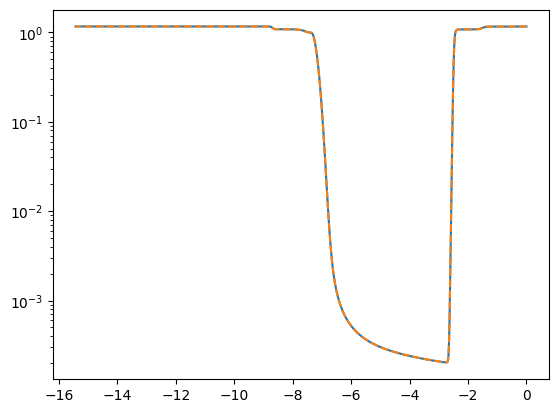

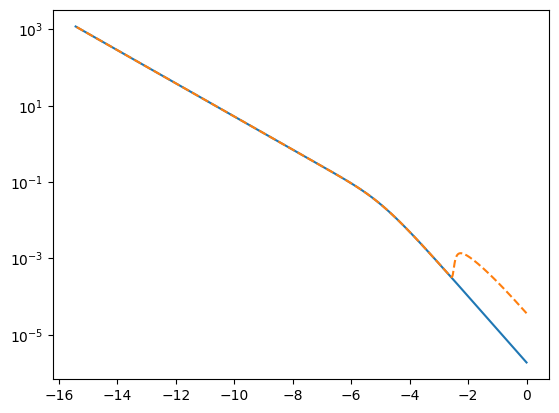

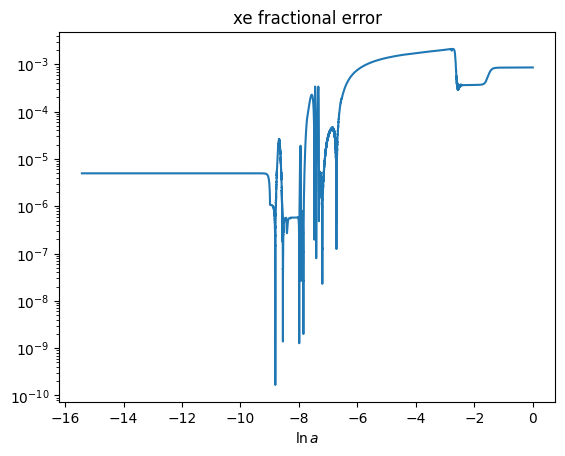

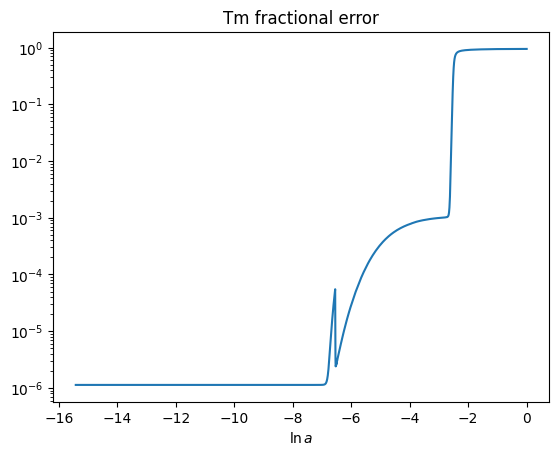

In [8]:
class_rec = class_lcdm.get_thermodynamics()
a = 1/(1.+class_rec["z"])
xe_class = class_rec["x_e"]
Tm_class = class_rec['Tb [K]'] * cnst.kB
xe_abcmb = BG.xe(jnp.log(a))
Tm_abcmb = BG.Tm(jnp.log(a))

plt.plot(jnp.log(a), xe_abcmb)
plt.plot(jnp.log(a), xe_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), Tm_abcmb)
plt.plot(jnp.log(a), Tm_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(xe_abcmb-xe_class)/xe_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("xe fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(Tm_abcmb-Tm_class)/Tm_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Tm fractional error")
plt.show()

In [18]:
expmkappa_class = class_rec["exp(-kappa)"]
g_class = class_rec["g [Mpc^-1]"]
expmkappa_abcmb = vmap(BG.expmkappa)(jnp.log(a))
g_abcmb = vmap(BG.visibility)(jnp.log(a))

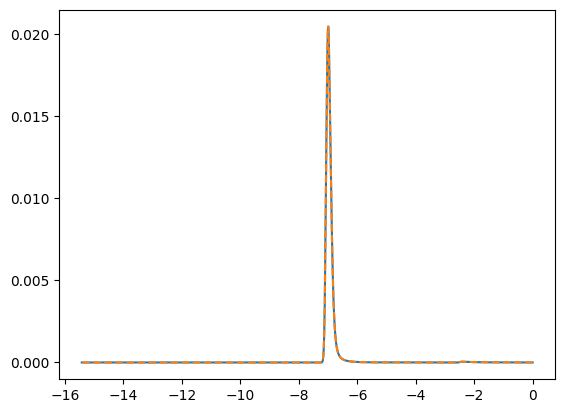

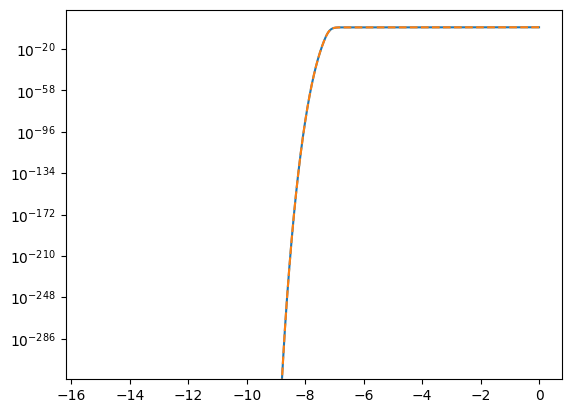

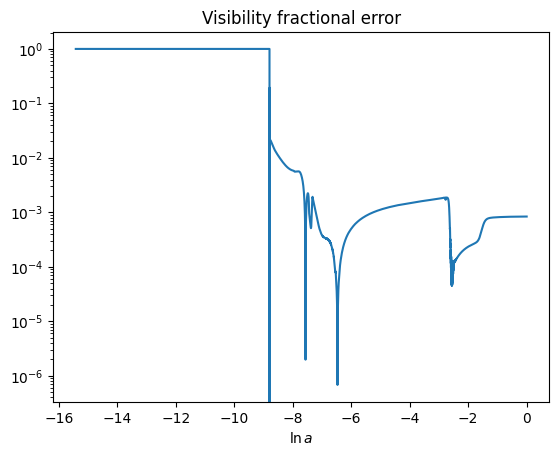

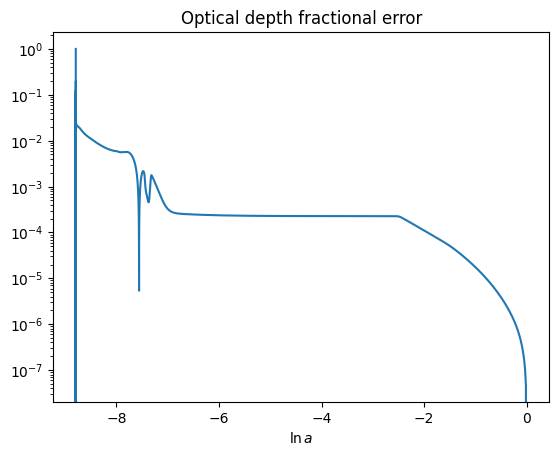

In [19]:
plt.plot(jnp.log(a), g_abcmb)
plt.plot(jnp.log(a), g_class, "--")
plt.show()

plt.plot(jnp.log(a), expmkappa_abcmb)
plt.plot(jnp.log(a), expmkappa_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(g_abcmb-g_class)/g_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("Visibility fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(expmkappa_abcmb-expmkappa_class)/expmkappa_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Optical depth fractional error")
plt.show()

# Cl's

In [12]:
if specs["lensing"]:
    class_ell = class_lcdm.lensed_cl(lmax)["ell"]
    class_tt = class_lcdm.lensed_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.lensed_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.lensed_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

else:
    class_ell = class_lcdm.raw_cl(lmax)["ell"]
    class_tt = class_lcdm.raw_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.raw_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.raw_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

ells = label[0]
abcmb_tt = ells*(ells+1)/2./jnp.pi * data[0]
abcmb_te = ells*(ells+1)/2./jnp.pi * data[1]
abcmb_ee = ells*(ells+1)/2./jnp.pi * data[2]

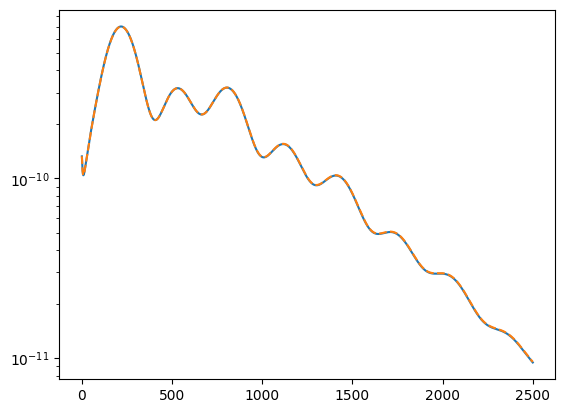

In [13]:
full_l = model.SS.ells
l = full_l[:]
plt.plot(l, abcmb_tt)
plt.plot(l, class_tt[l], "--")
plt.yscale("log")
plt.show()

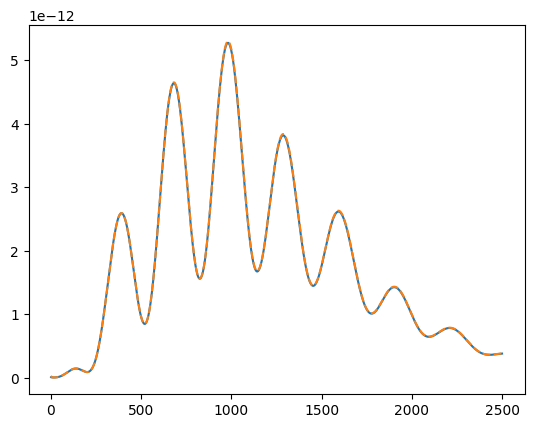

In [14]:
full_l = model.SS.ells
l = full_l[:]
plt.plot(l, abcmb_ee[l-2])
plt.plot(l, class_ee[l], "--")
plt.show()

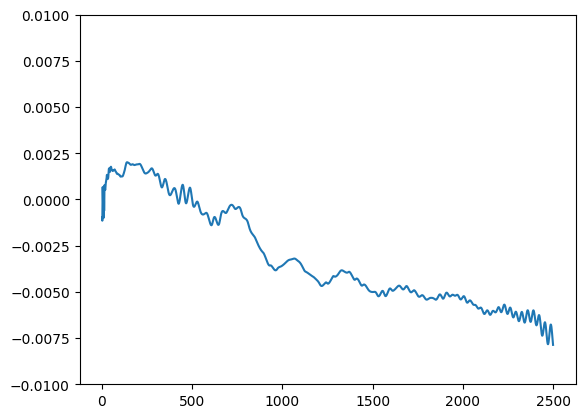

In [15]:
err = abcmb_tt[l-2]/class_tt[l] - 1.
plt.plot(l, err)
plt.ylim((-0.01, 0.01))
#plt.xlim((2, 2500))
plt.show()

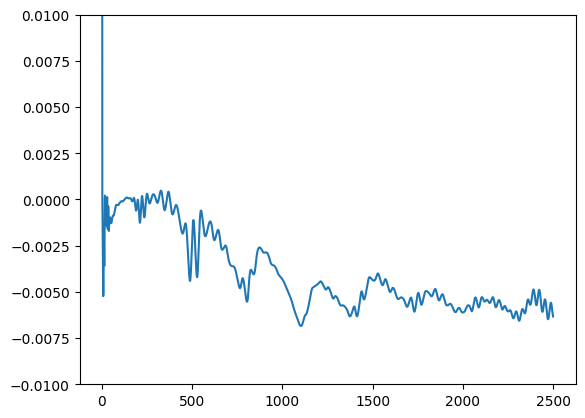

In [16]:
err = abcmb_ee[l-2]/class_ee[l] - 1.
plt.plot(l, err)
plt.ylim((-0.01, 0.01))
#plt.xlim((2, 2500))
plt.show()

## P(k)

In [242]:
class_dat = np.loadtxt("/home/zz1994/packages/class/output/ABCMB_test/neutrinos_pk.dat")
class_k  = class_dat[:, 0] * params["h"]
class_Pk = class_dat[:, 1] / params["h"]**3

In [243]:
abcmb_Pk = model.SS.Pk_lin(class_k, 0., PT, params)

In [246]:
PT.k.size

563

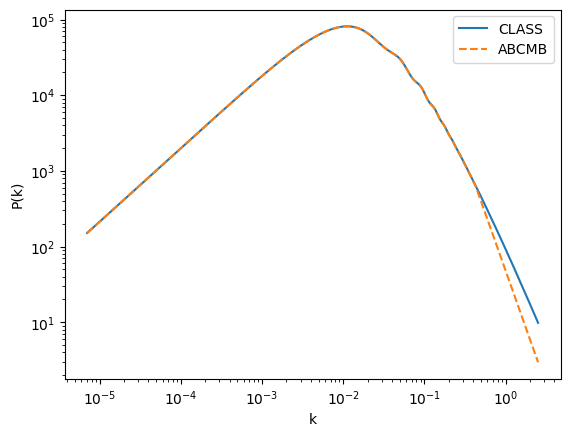

In [244]:
plt.loglog(class_k, class_Pk, label="CLASS")
plt.loglog(class_k, abcmb_Pk, "--", label="ABCMB")
plt.legend()
#plt.xlim((1.e-3, 1))
plt.xlabel("k")
plt.ylabel("P(k)")
plt.show()

In [7]:
from classy import Class

In [16]:
class_params = {
    "output": "mPk, lCl",
    "lensing": "yes",
    "z_max_pk": 1000,
    "H0": BG.params["h"]*100,
    "omega_b": BG.params["omega_b"],
    "omega_cdm": BG.params["omega_cdm"],
    "tau_reio": 0.0586,
    "N_ur": BG.params["N_ur"],
    "YHe": BG.params["YHe"],
    "lensing": "no",
    "N_ncdm": 0}    

In [17]:
class_lcdm = Class()
class_lcdm.set(class_params)
class_lcdm.compute()

In [18]:
zs = jnp.array([0., 10., 100., 1000.])
k = jnp.logspace(-4., -0.3, 500, base=10)

/state/partition1/job-66401383/ipykernel_1291522/4275723911.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


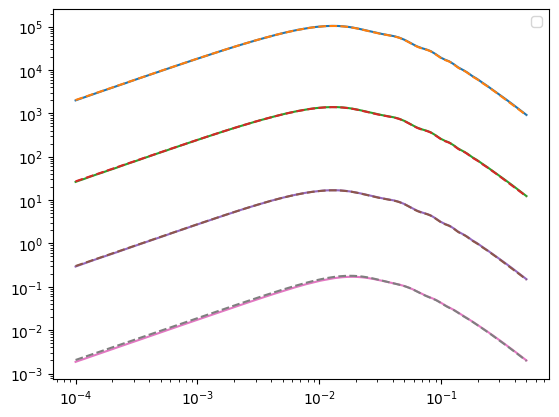

In [25]:
for z in zs:
    abcmb_res = SS.Pk_lin(k, z, PT, BG)
    class_res = np.vectorize(class_lcdm.pk_lin)(k, z)
    plt.loglog(k, SS.Pk_lin(k, z, PT, BG))
    plt.loglog(k, np.vectorize(class_lcdm.pk_lin)(k, z), "--")
    #plt.loglog(k, abs(abcmb_res - class_res)/class_res, label=z)
plt.legend()
plt.show()

# Lensing

## Lensing Cl

In [30]:
class_pp = class_lcdm.raw_cl(3000)["pp"]
class_tt = class_lcdm.raw_cl(3000)["tt"]
class_te = class_lcdm.raw_cl(3000)["te"]
class_ee = class_lcdm.raw_cl(3000)["ee"]
class_ell = class_lcdm.raw_cl(3000)["ell"]
abcmb_pp = vmap(SS.lensing_Cl, in_axes=(0, None, None))(class_ell, PT, BG)

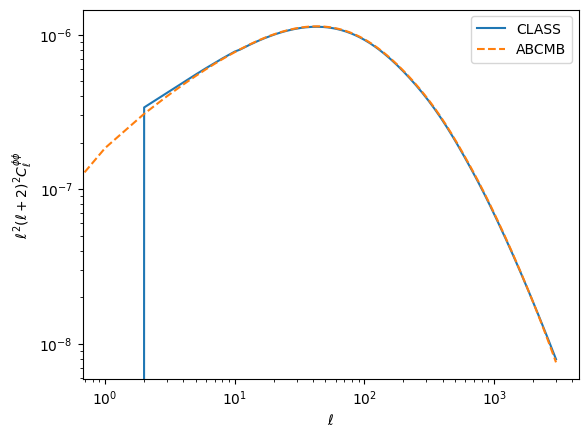

In [31]:
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * class_pp, label="CLASS")
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * abcmb_pp, "--", label="ABCMB")
plt.legend()
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell^2(\ell+2)^2C_\ell^{\phi\phi}$")
plt.show()

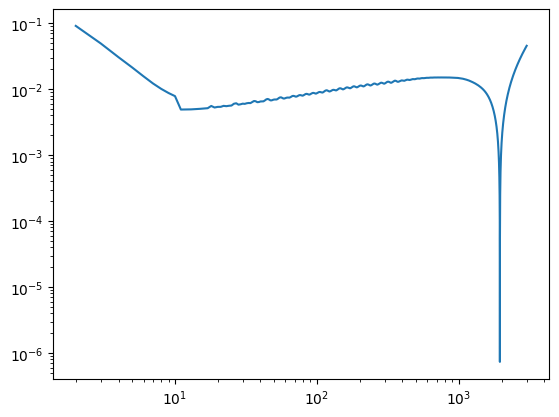

In [32]:
plt.plot(class_ell, abs(class_pp - abcmb_pp)/class_pp)
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.show()

## Temperature Cl

$$
C_\ell = \int_{0.98}^{1} \xi(\beta) J_0(\ell \beta) d\cos{\beta}
$$

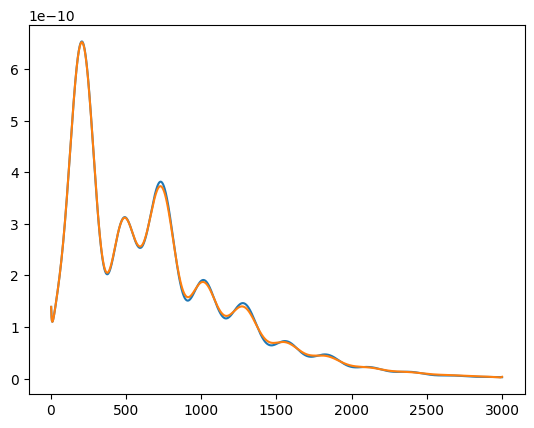

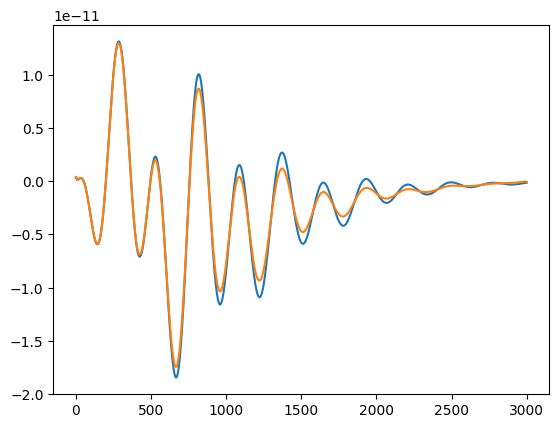

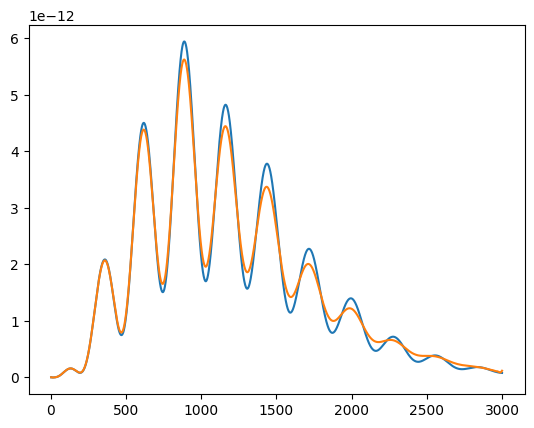

In [36]:
#res = SS.lense_ClTT(class_ell[2:], class_pp[2:], class_ell[2:]*(class_ell[2:]+1)*class_tt[2:]/2./jnp.pi)
#plt.loglog(class_ell[2:], class_ell[2:]*(class_ell[2:]+1)*res)
#ells = jnp.arange(2, 2000)
ells = class_ell[2:]
cltt = class_tt[2:]
clte = class_te[2:]
clee = class_ee[2:]
clpp = class_pp[2:]
pref = ells*(ells+1)/2./jnp.pi
#clpp = jnp.zeros(ells.size)
res_tt, res_te, res_ee = eqx.filter_jit(SS.lensed_Cls)(ells, cltt, clte, clee, PT, BG)
plt.plot(ells, pref*cltt)
plt.plot(ells, pref*(res_tt+cltt))
plt.show()

plt.plot(ells, pref*clte)
plt.plot(ells, pref*(res_te+clte))
plt.show()

plt.plot(ells, pref*clee)
plt.plot(ells, pref*(res_ee+clee))
plt.show()

In [47]:
f = eqx.filter_jit(SS.lensed_Cls)
for i in range(2):
    s = time.time()
    res_tt, res_te, res_ee = f(ells, cltt, clte, clee, PT, BG)
    res_tt.block_until_ready()
    print(time.time() - s)

16.553486347198486
11.142034769058228


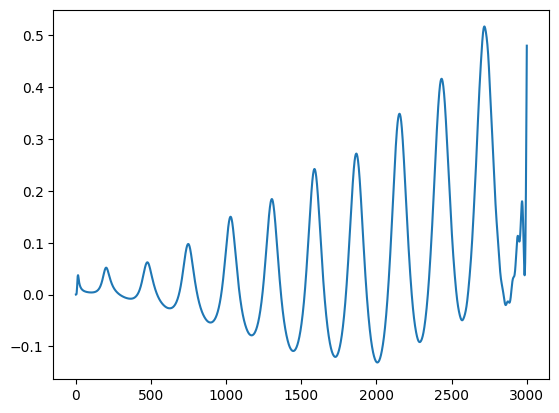

In [304]:
#plt.plot(ells, res_tt/cltt)
#plt.plot(ells, res_te/clte)
plt.plot(ells, res_ee/clee)
plt.show()

## Wigner Matrices

In [104]:
f = jit(tools.lensing_d00)
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1003)
mu    = jnp.cos(betas)
print(f(mu, l).shape)

(1000, 1001)


In [55]:
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1000)
mu    = jnp.cos(betas)

d00  = tools.lensing_d00(mu, l)
d11  = tools.lensing_d11(mu, l)
d1m1 = tools.lensing_d1m1(mu, l)
d2m2 = tools.lensing_d2m2(mu, l)

In the large $\ell$ limit, the Wigner matrices approach Bessel J functions as
$$
\lim_{\ell\rightarrow \infty}d_{mn}^{\ell}(\beta) \longrightarrow (-1)^{n-m} J_{m-n}(\ell \beta)\, .
$$
It serves to check the asymptotic behavior to make sure the recursion relations were correct.

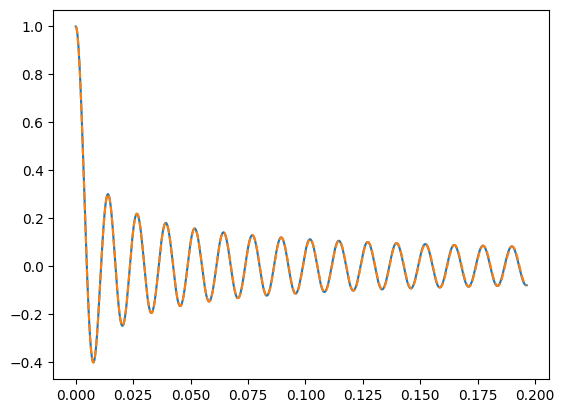

In [19]:
l = 500
plt.plot(betas, d00[:, l-2])
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

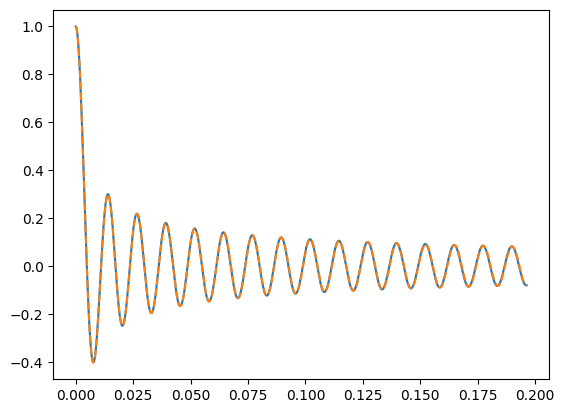

In [20]:
l = 500
plt.plot(betas, d11[:, l-2], label="d11")
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

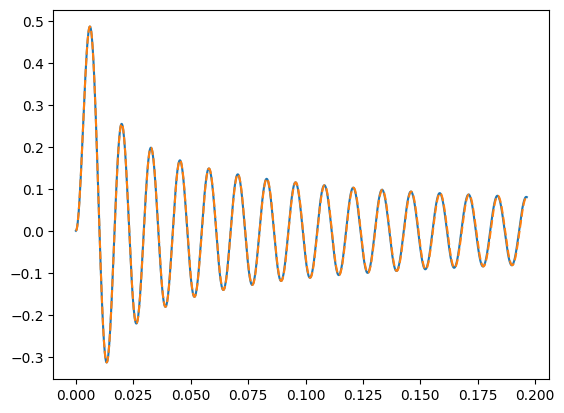

In [21]:
l = 500
plt.plot(betas, d1m1[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(2, l*betas), "--")
plt.show()

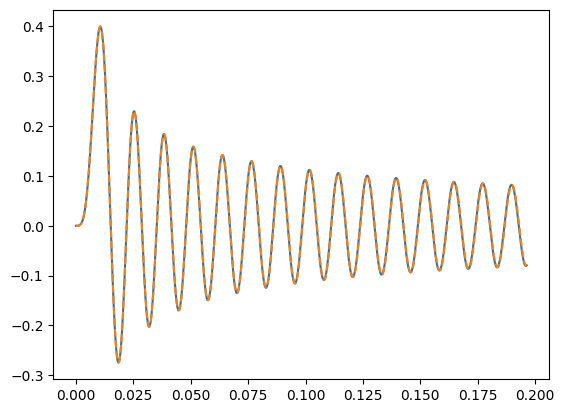

In [62]:
l = 500
plt.plot(betas, d2m2[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(4, l*betas), "--")
plt.show()

In [233]:
# Attempt at general solution
def wigner_d_matrix(mu, ells, m, n):
    """
    m, n are integers. m must be positive and greater than n.
    ells an array ([m, m+1, m+2, ..., ellmax])
    """
    
    # base case: ell = m
    def base_val(mu):
        beta = jnp.arccos(mu)
        norm = jnp.sqrt((2*m+1)/2) * jnp.sqrt(factorial(2*m)/(factorial(m+n)*factorial(m-n)))
        return norm * jnp.cos(beta/2.)**(m+n)*(-jnp.sin(beta/2.))**(m-n)
        #return norm * jnp.sqrt((1+mu)/2)**(m+n) * jnp.sqrt((1-mu)/2)**(m-n)

    normA = jnp.sqrt((2*ells+3)/(2*ells+1))
    normC = jnp.sqrt((2*ells+3)/(2*ells-1))
    denom = jnp.sqrt((ells+1)**2-m**2) * jnp.sqrt((ells+1)**2-n**2)
    A = jnp.nan_to_num(normA * (ells+1)*(2*ells+1) / denom, 0)
    B = jnp.nan_to_num(-A * m * n / ells / (ells+1), 0)
    C = jnp.nan_to_num(-normC * jnp.sqrt(ells**2-m**2) * jnp.sqrt(ells**2-n**2) / denom * (ells+1)/ells, 0)

    def one_mu(mu):
        d_start = base_val(mu) # Corresponds to ellmin = m
                
        def recursive_dlp1(carry, inputs):
            # For the first iteration, will take d1 and d2, compute d3.
            dl, dlm1 = carry 
            a, b, c = inputs

            # Compute dlp1
            dlp1 = a*mu*dl + b*dl + c*dlm1

            # Save dl, then make dl->dlm1, dlp1->dl
            return (dlp1, dl), dl

        # run scan for l = 2..lmax-1
        (_, _), res = lax.scan(recursive_dlp1, (d_start, 0.), (A, B, C))
        return res * jnp.sqrt(2./(2.*ells+1))

    return vmap(one_mu)(mu)

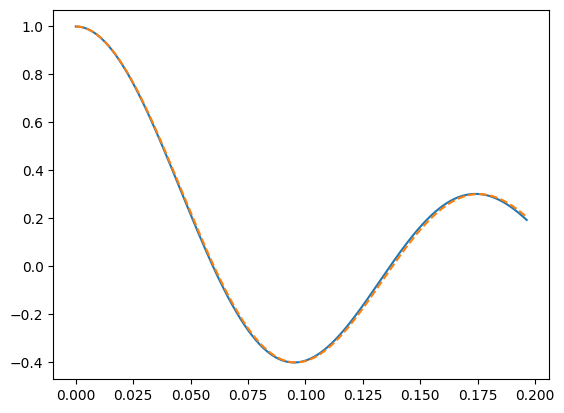

In [245]:
m = 4
n = 4
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(m, 1000)
mu    = jnp.cos(betas)
d = jit(wigner_d_matrix)(mu, l, m, n)

l_plot = 10*m
plt.plot(betas, d[:, l_plot-m])
plt.plot(betas, (-1)**(n-m)*scipy.special.jv(m-n, l_plot*betas), "--")
plt.show()

In [248]:
d.shape
zeros = jnp.zeros((mu.size, m-2))
d_patched = jnp.concatenate((zeros, d), axis=1)

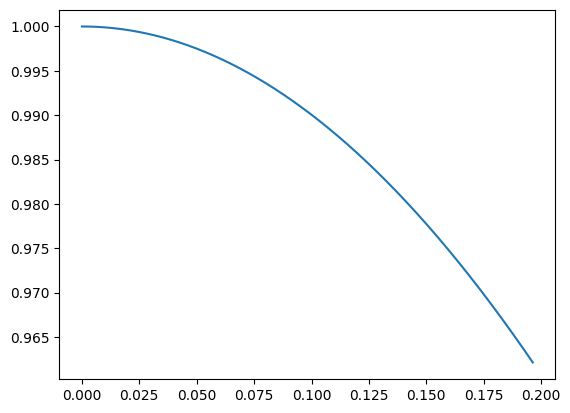

In [252]:
plt.plot(betas, d_patched[:, 2])

In [280]:
arr = jnp.ones(5)

5